# LeetCode #371: Sum of Two Integers

https://leetcode.com/problems/sum-of-two-integers/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (recursive add)** | $O(1)$ | $O(1)$ |
| **Optimal: Bit Manipulation (carry simulation) ★** | $O(1)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (recursive add)
Recursively add 1 or subtract 1 from both operands until one reaches zero. $O(|b|)$ recursive calls — slow for large values and risks stack overflow.

### Optimal: Bit Manipulation (carry simulation) ★
Simulate a binary adder: `a XOR b` gives the sum without carry; `(a AND b) << 1` gives the carry bits. Repeat until no carry remains. Guaranteed to terminate in at most 32 iterations.

**Why this is better than Brute Force:** Terminates in at most 32 iterations regardless of the magnitude of inputs; no recursion depth concerns.

**Constraints:**
* $-1000 \le a, b \le 1000$

## Solutions

### C#

In [ ]:
public int GetSum(int a, int b) {
    while (b != 0) {
        // Carry bits: positions where both a and b have a 1
        int carry = a & b;
        // Sum without carry: XOR gives bit-by-bit addition ignoring carry
        a ^= b;
        // Carry shifts left by 1 to add into the next bit position
        b = carry << 1;
    }
    return a;
}

### Python

In [ ]:
def getSum(self, a: int, b: int) -> int:
    mask = 0xFFFFFFFF
    while b & mask:
        # Carry bits: positions where both a and b have a 1
        carry = (a & b) << 1
        # Sum without carry via XOR
        a ^= b
        b = carry
    # Handle negative results in Python (arbitrary precision integers)
    return a if b == 0 else a & mask

### Go

In [ ]:
func getSum(a int, b int) int {
    for b != 0 {
        // Carry bits: positions where both a and b have a 1
        carry := a & b
        // Sum without carry via XOR
        a ^= b
        // Carry shifts left by 1 into the next bit position
        b = carry << 1
    }
    return a
}

### Rust

In [ ]:
pub fn get_sum(mut a: i32, mut b: i32) -> i32 {
    while b != 0 {
        // Carry bits: positions where both a and b have a 1
        let carry = a & b;
        // Sum without carry via XOR
        a ^= b;
        // Carry shifts left by 1 into the next bit position
        b = carry << 1;
    }
    a
}

## Example Scenarios

**1. Common Case**
**Input:** a=1, b=2
Iter 1: carry=0, a=1⊕2=3, b=0. No more carry. Return **3**.

**2. Slightly Complex**
**Input:** a=2, b=3
Iter 1: carry=2&3=2, a=2⊕3=1, b=4. Iter 2: carry=1&4=0, a=1⊕4=5, b=0. Return **5**. Two iterations needed due to carry propagation.

**3. Edge Case: Time Factor**
**Input:** a=-1 (all 32 bits set), b=1
Carry propagates through all 32 bits: each iteration clears one carry bit. Worst case: 32 iterations before b becomes 0. Result: **0** ($-1 + 1 = 0$).

**4. Edge Case: Space Factor**
**Input:** a=1000, b=1000
No recursion, no heap — only three 32-bit registers (a, b, carry). Space is $O(1)$. Result: **2000**. The `while` loop terminates after a few iterations.

**5. Almost-Impossible but Plausible**
**Input:** a=-1000, b=1000
In Python, XOR of arbitrary-precision negatives can grow unbounded without the mask. The mask `0xFFFFFFFF` trims to 32 bits each iteration, ensuring termination. Result: **0**. Demonstrates why Python needs special handling that C#/Go/Rust do not.

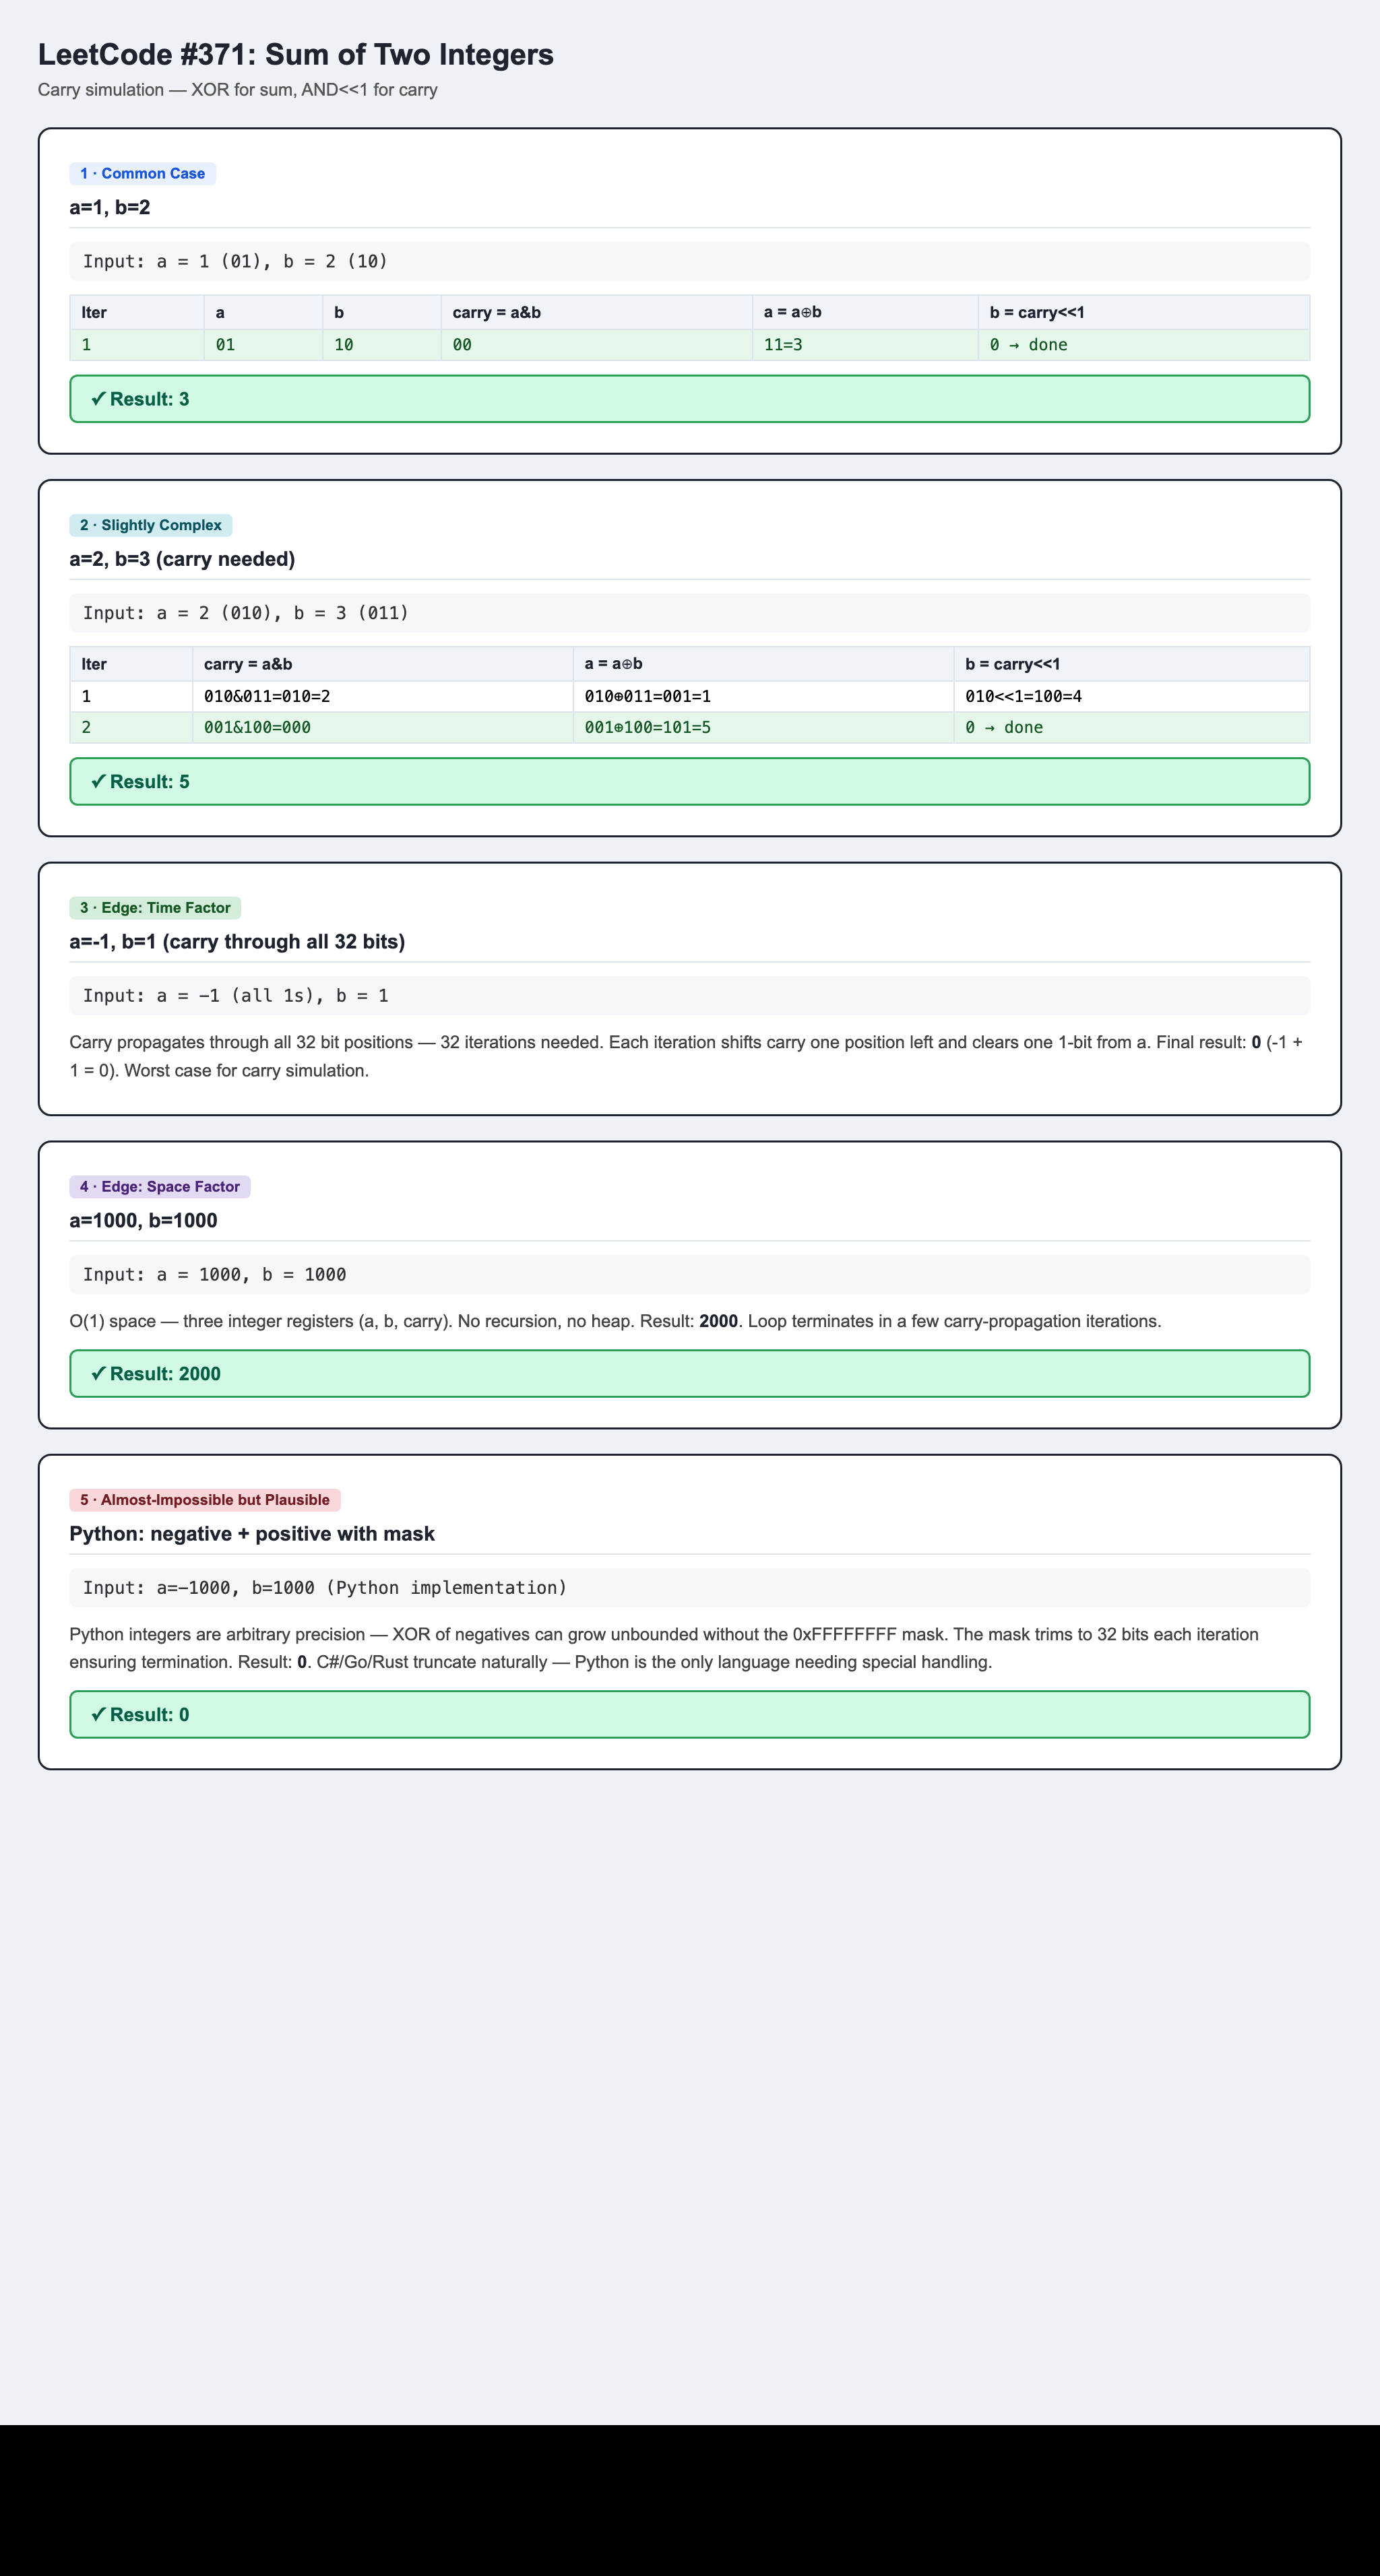